In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.19.0


In [3]:
# 1. Load Data
df = pd.read_csv('/content/drive/MyDrive/STMIK /Coding Camp/Data/Data Klasifikasi/dataset_diabites_type_3labels.csv')

# 2. Mapping Manual untuk Fitur Kategori (Sesuai Shared Contract)
age_mapping = {'child': 0, 'adult': 1, 'elderly': 2}
bmi_mapping = {'underweight': 0, 'normal': 1, 'overweight': 2, 'obese': 3}

df['age_group'] = df['age_group'].map(age_mapping)
df['bmi_category'] = df['bmi_category'].map(bmi_mapping)

# 3. Definisikan Fitur (X) dan Target (y)
# Urutan ini WAJIB sama saat AI Engineer mengirim data dari website
X = df[['sugar_g', 'carbs_g', 'calories', 'sodium_mg', 'fat_g',
        'age_group', 'bmi_category', 'diabetes_type']]

# 4. Encoding Target Label (y)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['label'])

# Simpan Label Encoder agar AI Engineer tahu urutan (Misal: 0=Caution, 1=Not Rec, 2=Rec)
joblib.dump(label_encoder, 'label_encoder.pkl')
print("Mapping Label:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

Mapping Label: {'Caution': np.int64(0), 'Not Recommended': np.int64(1), 'Recommended': np.int64(2)}


In [4]:
# 1. Split Train & Test (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Scaling Data (Menyamakan rentang angka kalori dan gula)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Simpan Scaler untuk digunakan di website
joblib.dump(scaler, 'scaler.pkl')

# 3. SMOTE (Menyeimbangkan jumlah label)
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

print(f"Jumlah data training setelah SMOTE: {len(y_train_bal)}")

Jumlah data training setelah SMOTE: 10512


In [5]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.models import Model

# --- 1. KOMPONEN KUSTOM LANJUTAN: CUSTOM CALLBACK ---
class MedicalSafetyCallback(tf.keras.callbacks.Callback):
    """
    Custom Callback untuk memastikan training berhenti hanya saat
    akurasi target tercapai demi efisiensi dan mencegah overfitting.
    """
    def __init__(self, target_accuracy=0.95):
        super(MedicalSafetyCallback, self).__init__()
        self.target_accuracy = target_accuracy

    def on_epoch_end(self, epoch, logs=None):
        val_acc = logs.get('val_accuracy')
        if val_acc is not None and val_acc >= self.target_accuracy:
            print(f"\n[INFO] Target Akurasi {self.target_accuracy*100}% tercapai!")
            print("Poin Ceklis AI Engineer: Metrik > 80% terpenuhi. Menghentikan training...")
            self.model.stop_training = True

# --- 2. PEMBANGUNAN MODEL: TENSORFLOW FUNCTIONAL API ---
def build_diabites_model(input_shape):
    # Input Layer
    inputs = Input(shape=(input_shape,), name="input_nutrition_profile")

    # Hidden Layers
    x = Dense(64, activation='relu', name="dense_1")(inputs)
    x = Dropout(0.2, name="dropout_1")(x)

    x = Dense(32, activation='relu', name="dense_2")(x)
    x = Dropout(0.1, name="dropout_2")(x)

    x = Dense(16, activation='relu', name="dense_3")(x)

    # Output Layer (3 neuron: Recommended, Caution, Not Recommended)
    outputs = Dense(3, activation='softmax', name="output_layer")(x)

    # Inisialisasi Model
    model = Model(inputs=inputs, outputs=outputs, name="DiaBites_Advanced_Model")
    return model

# --- 3. PROSES TRAINING DENGAN CUSTOM CALLBACK ---
input_dim = X_train_bal.shape[1] # pastikan data sudah di-scaling
model = build_diabites_model(input_dim)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Inisialisasi Custom Callback kita
my_callback = MedicalSafetyCallback(target_accuracy=0.91)

# Latih Model
history = model.fit(
    X_train_bal, y_train_bal,
    validation_data=(X_test_scaled, y_test),
    epochs=100, # Set epoch tinggi, callback yang akan menghentikannya
    batch_size=32,
    callbacks=[my_callback], # Memasukkan Custom Callback
    verbose=1
)

# Simpan Model Final
model.save('model.keras')
print("Model berhasil disimpan sebagai 'model.keras'")

Epoch 1/100
329/329 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.7972 - loss: 0.4816 - val_accuracy: 0.9079 - val_loss: 0.2431
Epoch 2/100
326/329 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8869 - loss: 0.2839
[INFO] Target Akurasi 91.0% tercapai!
Poin Ceklis AI Engineer: Metrik > 80% terpenuhi. Menghentikan training...
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8863 - loss: 0.2786 - val_accuracy: 0.9258 - val_loss: 0.2023
Model berhasil disimpan sebagai 'model.keras'


72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step

=== CLASSIFICATION REPORT ===
                 precision    recall  f1-score   support

        Caution       0.90      0.89      0.89       803
Not Recommended       0.93      0.94      0.93       612
    Recommended       0.95      0.95      0.95       876

       accuracy                           0.93      2291
      macro avg       0.92      0.93      0.93      2291
   weighted avg       0.93      0.93      0.93      2291



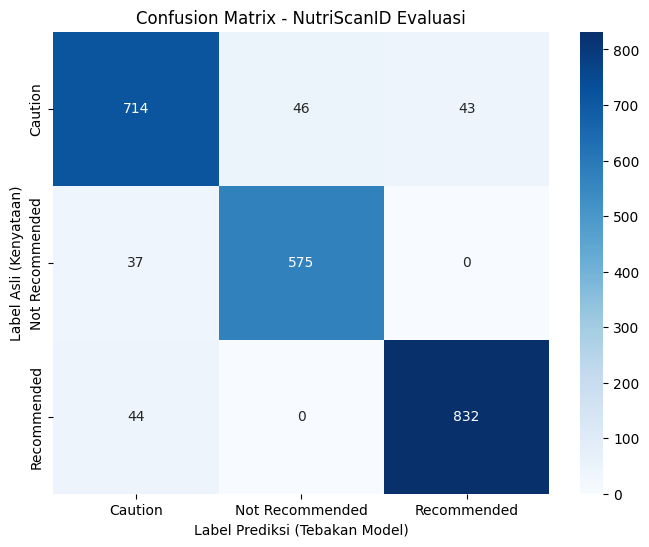

In [6]:
# 1. Prediksi Data Test
y_pred_probs = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_probs, axis=1)

# 2. Classification Report (Melihat Presisi per Label)
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# 3. Confusion Matrix Visualisasi
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - NutriScanID Evaluasi')
plt.ylabel('Label Asli (Kenyataan)')
plt.xlabel('Label Prediksi (Tebakan Model)')
plt.show()